In [8]:
import zipfile
import os
from keras.utils import to_categorical
import numpy as np

In [2]:
# Step 1: Extracting the data
def extract_data(zip_file_path, extraction_directory):
    os.makedirs(extraction_directory, exist_ok=True)
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extraction_directory)

def list_extracted_directories(extraction_directory):
    extracted_files = os.listdir(extraction_directory)
    return extracted_files

In [3]:
# Step 2: Accessing the extracted data
def access_extracted_data(extraction_directory):
    data_directory = os.path.join(extraction_directory, 'flowers')
    categories = os.listdir(data_directory)
    return categories

In [4]:
# Step 3: Preprocessing the data
def preprocess_data(categories, data_directory):
    import cv2
    import numpy as np
    from sklearn.model_selection import train_test_split

    image_size = (64, 64)
    validation_split = 0.2

    data = []
    labels = []

    for category in categories:
        category_path = os.path.join(data_directory, category)
        for img_name in os.listdir(category_path):
            img_path = os.path.join(category_path, img_name)
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.resize(img, image_size)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = img / 255.0
                data.append(img)
                labels.append(category)

    data = np.array(data, dtype="float32")
    labels = np.array(labels)

    from sklearn.preprocessing import LabelEncoder
    encoder = LabelEncoder()
    labels_encoded = encoder.fit_transform(labels)

    train_images, val_images, train_labels, val_labels = train_test_split(data, labels_encoded, test_size=validation_split, random_state=42)

    train_images_flattened = train_images.reshape(train_images.shape[0], -1)
    val_images_flattened = val_images.reshape(val_images.shape[0], -1)

    return train_images_flattened, val_images_flattened, train_labels, val_labels


In [5]:
# Step 4: Building the MLP model
class MyNeuralNetwork:
    def __init__(self, input_dim, hidden_layers, output_dim):
        self.layers = hidden_layers
        self.weights = []
        self.biases = []
        layer_sizes = [input_dim] + hidden_layers + [output_dim]

        for i in range(len(layer_sizes) - 1):
            self.weights.append(np.random.randn(layer_sizes[i], layer_sizes[i+1]) * 0.01)
            self.biases.append(np.zeros((1, layer_sizes[i+1])))

    def relu(self, x):
        return np.maximum(0, x)

    def softmax(self, x):
        e_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return e_x / np.sum(e_x, axis=1, keepdims=True)

    def forward_pass(self, X):
        activations = [X]
        for i in range(len(self.layers)):
            z = np.dot(activations[-1], self.weights[i]) + self.biases[i]
            a = self.relu(z)
            activations.append(a)
        z = np.dot(activations[-1], self.weights[-1]) + self.biases[-1]
        y = self.softmax(z)
        activations.append(y)
        return activations

    def compute_loss(self, y_pred, y_true):
        m = y_true.shape[0]
        p = np.clip(y_pred, 1e-15, 1 - 1e-15)
        return -np.sum(y_true * np.log(p)) / m

    def backward_pass(self, activations, Y):
        L = len(activations)
        grads_w = [None] * len(self.weights)
        grads_b = [None] * len(self.biases)
        delta = activations[-1] - Y

        for i in reversed(range(L-1)):
            grads_w[i] = np.dot(activations[i].T, delta)
            grads_b[i] = np.sum(delta, axis=0, keepdims=True)
            if i > 0:
                delta = np.dot(delta, self.weights[i].T) * (activations[i] > 0)

        return grads_w, grads_b

    def update_params(self, grads_w, grads_b, lr):
        for i in range(len(self.weights)):
            self.weights[i] -= lr * grads_w[i]
            self.biases[i] -= lr * grads_b[i]

    def train(self, X, Y, epochs, lr):
        for epoch in range(epochs):
            activations = self.forward_pass(X)
            loss = self.compute_loss(activations[-1], Y)
            grads_w, grads_b = self.backward_pass(activations, Y)
            self.update_params(grads_w, grads_b, lr)
            print(f'Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}')

    def predict(self, X):
        activations = self.forward_pass(X)
        return np.argmax(activations[-1], axis=1)

    def evaluate(self, X, Y):
        predictions = self.predict(X)
        accuracy = np.mean(predictions == np.argmax(Y, axis=1))
        return accuracy


In [6]:
# Step 5: Training and evaluating the model
def train_and_evaluate_model(train_images, val_images, train_labels, val_labels, num_classes, hidden_layers, epochs=50, lr=0.01):
    from sklearn.preprocessing import label_binarize
    from sklearn.metrics import classification_report
    from sklearn.metrics import roc_curve, auc
    import matplotlib.pyplot as plt

    train_labels_one_hot = to_categorical(train_labels)
    val_labels_one_hot = to_categorical(val_labels)

    np.random.seed(42)
    input_dim = train_images.shape[1]
    output_dim = num_classes

    model = MyNeuralNetwork(input_dim=input_dim, hidden_layers=hidden_layers, output_dim=output_dim)
    model.train(train_images, train_labels_one_hot, epochs=epochs, lr=lr)
    accuracy = model.evaluate(val_images, val_labels_one_hot)
    print(f'Validation Accuracy: {accuracy * 100:.2f}%')

    val_predictions = model.predict(val_images)
    val_labels = np.argmax(val_labels_one_hot, axis=1)
    val_report = classification_report(val_labels, val_predictions, target_names=[f'Class_{i}' for i in range(num_classes)])
    print("Validation Classification Report:")
    print(val_report)

    val_labels_binarized = label_binarize(val_labels, classes=np.arange(num_classes))
    val_fpr = []
    val_tpr = []
    val_auc = []

    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(val_labels_binarized[:, i], val_predictions)
        val_fpr.append(fpr)
        val_tpr.append(tpr)
        val_auc.append(auc(fpr, tpr))

    plt.figure(figsize=(8, 6))
    for i in range(num_classes):
        plt.plot(val_fpr[i], val_tpr[i], label=f'Class_{i} (AUC = {val_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve (Validation Set)')
    plt.legend(loc="lower right")
    plt.show()

Epoch 1/30, Loss: 1.6096
Epoch 2/30, Loss: 1.5981
Epoch 3/30, Loss: 1.5932
Epoch 4/30, Loss: 1.5718
Epoch 5/30, Loss: 1.8535
Epoch 6/30, Loss: 21.4577
Epoch 7/30, Loss: 7.8904
Epoch 8/30, Loss: 26.2467
Epoch 9/30, Loss: 26.5868
Epoch 10/30, Loss: 26.2467
Epoch 11/30, Loss: 28.5573
Epoch 12/30, Loss: 28.2472
Epoch 13/30, Loss: 28.5573
Epoch 14/30, Loss: 4.2898
Epoch 15/30, Loss: 2.7383
Epoch 16/30, Loss: 2.2720
Epoch 17/30, Loss: 1.9015
Epoch 18/30, Loss: 1.6909
Epoch 19/30, Loss: 1.6223
Epoch 20/30, Loss: 1.6047
Epoch 21/30, Loss: 1.6002
Epoch 22/30, Loss: 1.5993
Epoch 23/30, Loss: 1.5991
Epoch 24/30, Loss: 1.5991
Epoch 25/30, Loss: 1.5991
Epoch 26/30, Loss: 1.5991
Epoch 27/30, Loss: 1.5991
Epoch 28/30, Loss: 1.5991
Epoch 29/30, Loss: 1.5991
Epoch 30/30, Loss: 1.5991
Validation Accuracy: 25.81%


D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Validation Classification Report:
              precision    recall  f1-score   support

     Class_0       0.00      0.00      0.00       162
     Class_1       0.26      1.00      0.41       223
     Class_2       0.00      0.00      0.00       155
     Class_3       0.00      0.00      0.00       135
     Class_4       0.00      0.00      0.00       189

    accuracy                           0.26       864
   macro avg       0.05      0.20      0.08       864
weighted avg       0.07      0.26      0.11       864



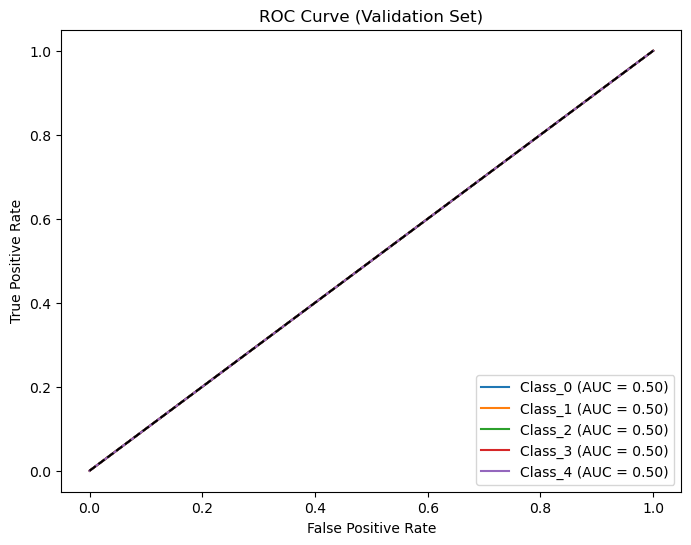

In [9]:
if __name__ == "__main__":
    # Step 1
    extract_data('archive.zip', 'my_flowers')
    extracted_directories = list_extracted_directories('my_flowers')
    
    # Step 2
    categories = access_extracted_data('my_flowers')
    
    if categories is not None:
        data_directory = os.path.join('my_flowers', 'flowers')  # 'flowers' is the extracted folder
        train_images, val_images, train_labels, val_labels = preprocess_data(categories, data_directory)
    else:
        print("Dataset directory not found. Exiting program.")
        exit(1)
    
    # Step 5
    train_and_evaluate_model(train_images, val_images, train_labels, val_labels, len(categories), hidden_layers=[256, 128], epochs=30, lr=0.001)